<a href="https://colab.research.google.com/github/tanviupadhyay1517/Hypothesis-Testing-/blob/main/Paired_t_test_Galbladder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Case Study:**
 A doctor examined gallbladder function before and after fundoplication— a surgery used to stop stomach contents from flowing back into the esophagus (reflux)—in patients with gastroesophageal reflux disease. The doctor measured gallbladder functionality by calculating the gallbladder ejection fraction (GBEF) before and after fundoplication. The goal of fundoplication is to increase GBEF, which is measured as a percent. The data is given in Galbladder.xlsx. We wish to know if these data provide sufficient evidence to allow us to conclude that fundoplication increases GBEF functioning.

In [1]:
# Import necessary packages
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Read data
df1 = pd.read_excel('/content/drive/MyDrive/Classroom/FTN Batch 10/T test Two sample/Galbladder.xlsx')

# Exploratory Analysis

In [4]:
df1.columns

Index(['Before_op', 'After_op'], dtype='object')

In [5]:
df1.head()                                  # Viewing first few observations of the data

,Before_op,After_op
0,22.0,63.5
1,63.3,91.5
2,96.0,59.0
3,9.2,37.8
4,3.1,10.1


In [6]:
df1.describe()                              # Descriptive statistics

,Before_op,After_op
count,12.000000,12.000000
mean,38.533333,56.608333
std,30.058680,27.800113
min,0.000000,10.100000
25%,16.400000,39.450000
50%,33.500000,57.000000
75%,63.475000,86.450000
max,96.000000,91.500000


In [7]:
# Taking difference
df1['errors_diff'] = df1['After_op'] - df1['Before_op']
df1['errors_diff'].describe()

,errors_diff
count,12.000000
mean,18.075000
std,32.681691
min,-37.000000
25%,6.750000
50%,20.400000
75%,30.500000
max,88.000000


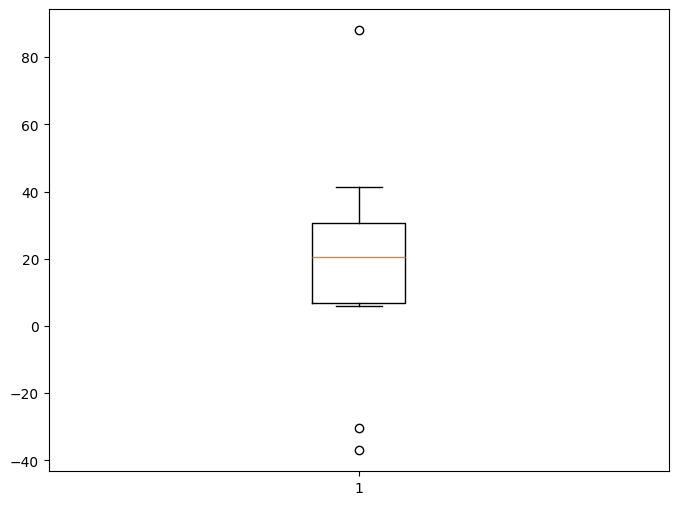

In [8]:
# Boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(df1['errors_diff'])
plt.show()

In [9]:
# Checking Normality using Shapiro test
Shapiro1=stats.shapiro(df1['errors_diff'])
Shapiro1

ShapiroResult(statistic=np.float64(0.9351613693585978), pvalue=np.float64(0.43803685675735926))

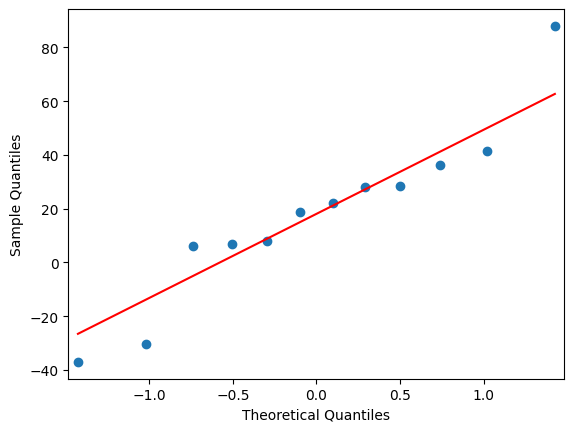

In [10]:
# Checking Normality using Q-Q plot
from statsmodels.graphics.gofplots import qqplot
from matplotlib import pyplot

qqplot(df1['errors_diff'],line='s')
plt.show()

In [11]:
# Paired t test / t test for dependent samples

ttest=stats.ttest_rel(df1['After_op'] , df1['Before_op'], alternative ='greater')
ttest

TtestResult(statistic=np.float64(1.9158627953210292), pvalue=np.float64(0.04086216554687442), df=np.int64(11))

In [12]:
print("Average errors before training:", df1['Before_op'].mean())
print("Average errors after training :", df1['After_op'].mean())

Average errors before training: 38.53333333333334
Average errors after training : 56.60833333333333
